In [ ]:
#clone pretrained library
!git clone https://github.com/breizhn/DTLN.git

In [6]:
%cd DTLN

D:\jupyter_python\AI_ML repo\Week 4\DTLN


DTLN is cloned and the pretrained model is downloaded

In [7]:
#importing libraries
import librosa
import librosa.display
import librosa.feature
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

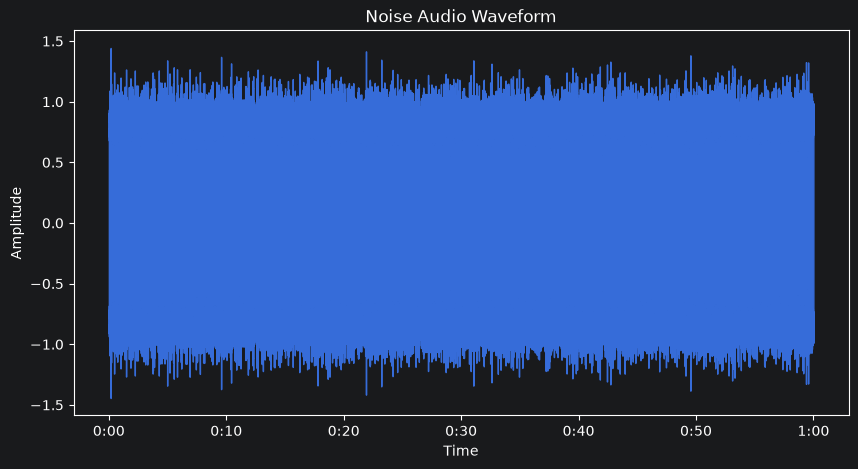

In [8]:
#Loading noise audio
audio_path = "noisy_audio\\white_noise.wav"
audio, sr = librosa.load(audio_path)

plt.figure(figsize=(10,5))
librosa.display.waveshow(audio)
plt.title("Noise Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

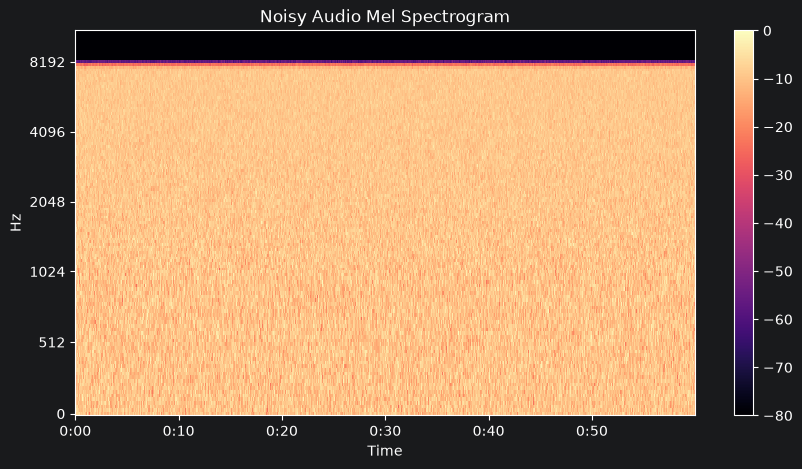

In [9]:
# Spectrogram

mel_spect = librosa.feature.melspectrogram(y=audio,sr=sr)

mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(mel_spect_db,sr=sr,x_axis='time',y_axis='mel')
plt.colorbar()
plt.title("Noisy Audio Mel Spectrogram")
plt.show()

In [11]:
!python real_time_processing.py

Processing finished.


I0000 00:00:1785809427.062232   24532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785809429.790100   24532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785809432.472393   24532 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [13]:
#Loading denoise
denoise_path = "noisy_audio\\out.wav"
denoised, sr = librosa.load(denoise_path,sr=16000)

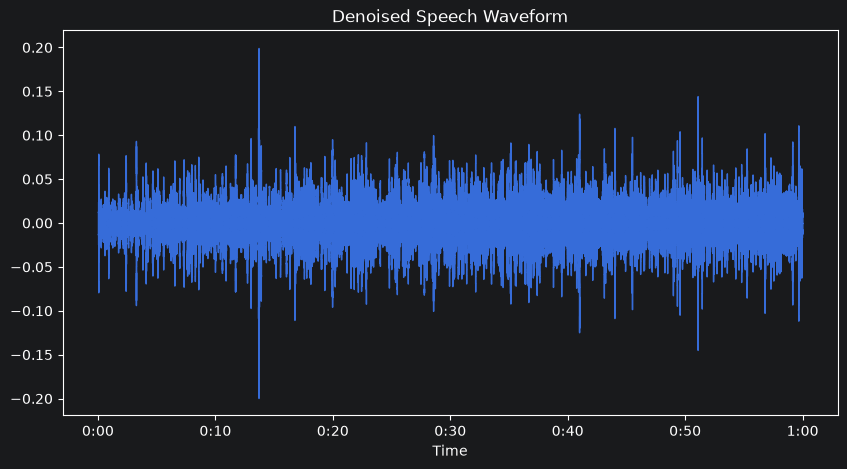

In [14]:
plt.figure(figsize=(10,5))

librosa.display.waveshow(denoised,sr=sr)

plt.title("Denoised Speech Waveform")

plt.show()

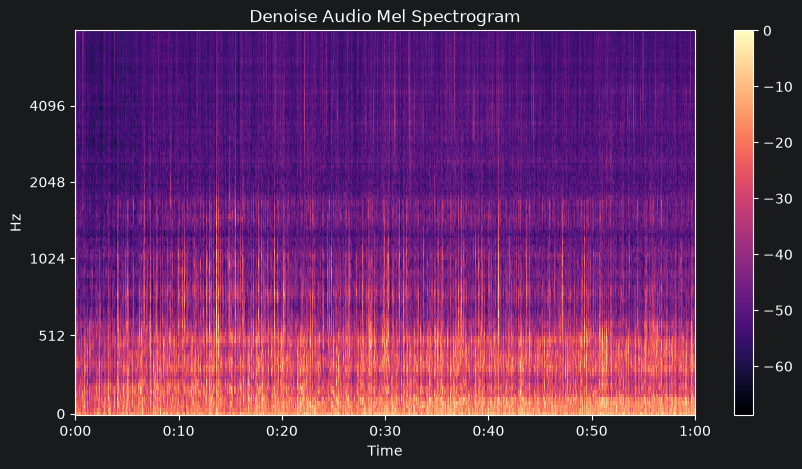

In [15]:
#Mel Spectrum of denoised


mel_spect_dn = librosa.feature.melspectrogram(y=denoised,sr=sr)

mel_spect_dn_db = librosa.power_to_db(mel_spect_dn, ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(mel_spect_dn_db,sr=sr,x_axis='time',y_axis='mel')
plt.colorbar()
plt.title("Denoise Audio Mel Spectrogram")
plt.show()

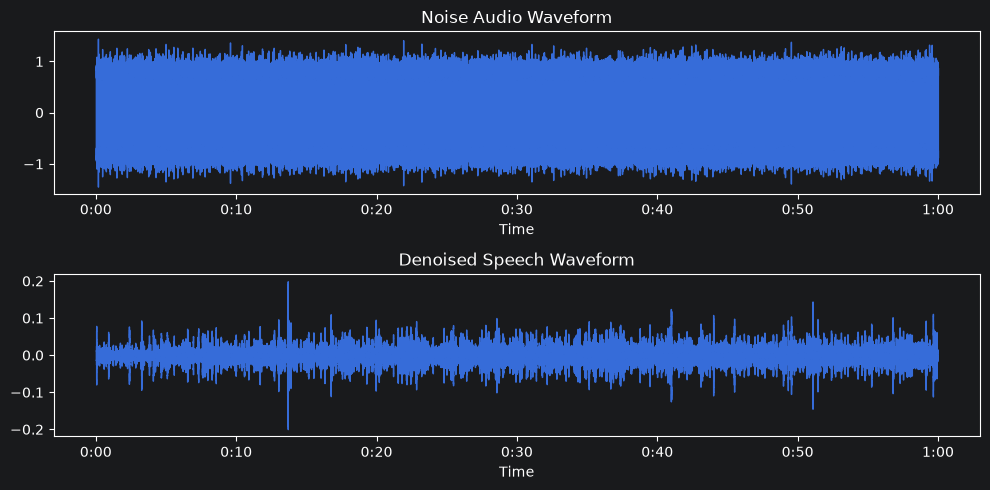

In [17]:
plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
librosa.display.waveshow(audio)
plt.title("Noise Audio Waveform")


plt.subplot(2,1,2)
librosa.display.waveshow(denoised,sr=sr)
plt.title("Denoised Speech Waveform")

plt.tight_layout()
plt.show()

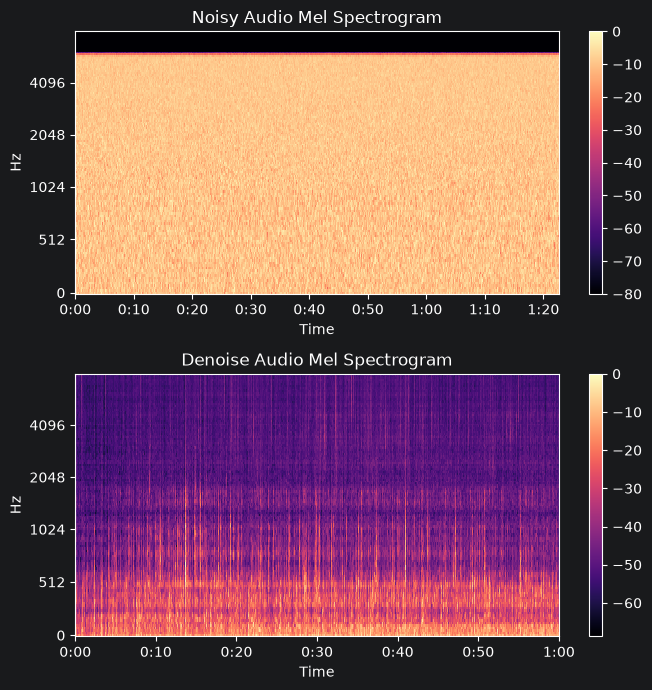

In [20]:
plt.figure(figsize=(7,7))

plt.subplot(2,1,1)
librosa.display.specshow(mel_spect_db,sr=sr,x_axis='time',y_axis='mel')
plt.colorbar()
plt.title("Noisy Audio Mel Spectrogram")

plt.subplot(2,1,2)
librosa.display.specshow(mel_spect_dn_db,sr=sr,x_axis='time',y_axis='mel')
plt.colorbar()
plt.title("Denoise Audio Mel Spectrogram")

plt.tight_layout()
plt.show()